### **Import the necessary libraries**

In [1]:
import nltk
import spacy 

import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline

### **Load the dataset**

In [1]:
%%capture
from datasets import load_dataset

dataset = load_dataset("ncduy/mt-en-vi")

In [3]:
dataset

DatasetDict({
    train: Dataset({
        features: ['en', 'vi', 'source'],
        num_rows: 2884451
    })
    validation: Dataset({
        features: ['en', 'vi', 'source'],
        num_rows: 11316
    })
    test: Dataset({
        features: ['en', 'vi', 'source'],
        num_rows: 11225
    })
})

Here, we can see this dataset contains three splits (train, validation, and test) for an English–Vietnamese corpus. Each split has the same features: `['en', 'vi', 'source']`, indicating that each sample includes an English sentence, a Vietnamese sentence, and a metadata field for the data source. The training set is notably large, with over 2.8 million rows, while the validation and test sets are much smaller, around 11k rows each.

In [4]:
train = dataset['train'].to_pandas()
val = dataset['validation'].to_pandas()
test = dataset['test'].to_pandas()

In [6]:
envi_data = pd.concat(
    [
        train, 
        val,
        test
    ]
)
envi_data.reset_index(drop=True, inplace=True)

In [7]:
envi_data.head()

,en,vi,source
0,"- Sorry, that question's not on here.","- Xin lỗi, nhưng mà ở đây không có câu hỏi đấy.",OpenSubtitles v2018
1,He wants you to come with him immediately.,Ông ấy muốn bố đi với ông ấy ngay lập tức,OpenSubtitles v2018
2,I thought we could use some company.,Tôi nghĩ chúng ta có thể muốn vài người bạn đồ...,OpenSubtitles v2018
3,It was founded in 2008 by this anonymous progr...,Nó được sáng lập vào năm 2008 bởi một lập trìn...,TED2020 v1
4,"With both of these methods, no two prints are ...","Với cả hai phương pháp, không có hai bản in nà...",TED2020 v1


In [8]:
envi_data.tail()

,en,vi,source
2906987,It's important.,Đây là điều quan trọng.,TED2020 v1
2906988,I looked at him and I saw myself.,"Mình nhìn vào nó, và nhìn thấy chính con người...",OpenSubtitles v2018
2906989,In India it is distributed mainly on the plain...,"Tại Ấn Độ, nó phân bố chủ yếu trên các vùng đồ...",WikiMatrix v1
2906990,He moved to MIO Biwako Shiga in 2015.,Anh chuyển đến MIO Biwako Shiga năm 2015.,WikiMatrix v1
2906991,The words genius and musical are used in the s...,Những từ ngữ như thiên tài âm nhạc đã được sử ...,wikimedia v20210402


In [9]:
envi_data.shape

(2906992, 3)

In [10]:
envi_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2906992 entries, 0 to 2906991
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   en      object
 1   vi      object
 2   source  object
dtypes: object(3)
memory usage: 66.5+ MB


### **Check for duplicated values**

In [11]:
envi_data.duplicated().sum()

0

We can see here, this dataset doesn't have any duplicated values

### **Check for missing values**

In [12]:
envi_data.isnull().sum()

en        0
vi        0
source    0
dtype: int64

This dataset doesn't have any missing values

### **Basic Statistics**

**Word Count**

In [13]:
envi_data['en_words_count'] = envi_data['en'].apply(lambda x: len(x.split()))
envi_data['vi_words_count'] = envi_data['vi'].apply(lambda x: len(x.split()))

In [14]:
print(f"The number of English words count: {envi_data['en_words_count'].sum()} words")

The number of English words count: 40262004 words


In [15]:
print(f"The number of Vietnamese words count: {envi_data['vi_words_count'].sum()} words")

The number of Vietnamese words count: 52327394 words


In [16]:
envi_data.describe().map('{:,.2f}'.format)

,en_words_count,vi_words_count
count,"2,906,992.00","2,906,992.00"
mean,13.85,18.00
std,9.94,13.66
min,1.00,1.00
25%,7.00,8.00
50%,11.00,13.00
75%,18.00,24.00
max,"1,329.00","1,358.00"


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def boxplot_sentence_lengths(sentence_lengths, language="English", color="skyblue"):
    plt.figure(figsize=(15, 7), dpi=300)
    sns.set_style('darkgrid')
    sns.boxplot(x=sentence_lengths, color=color)
    plt.xlabel('Sentence Length (words)', fontsize=12)
    plt.title(f'Boxplot of {language} Sentence Lengths', fontsize=14, fontweight='bold')

    plt.show()

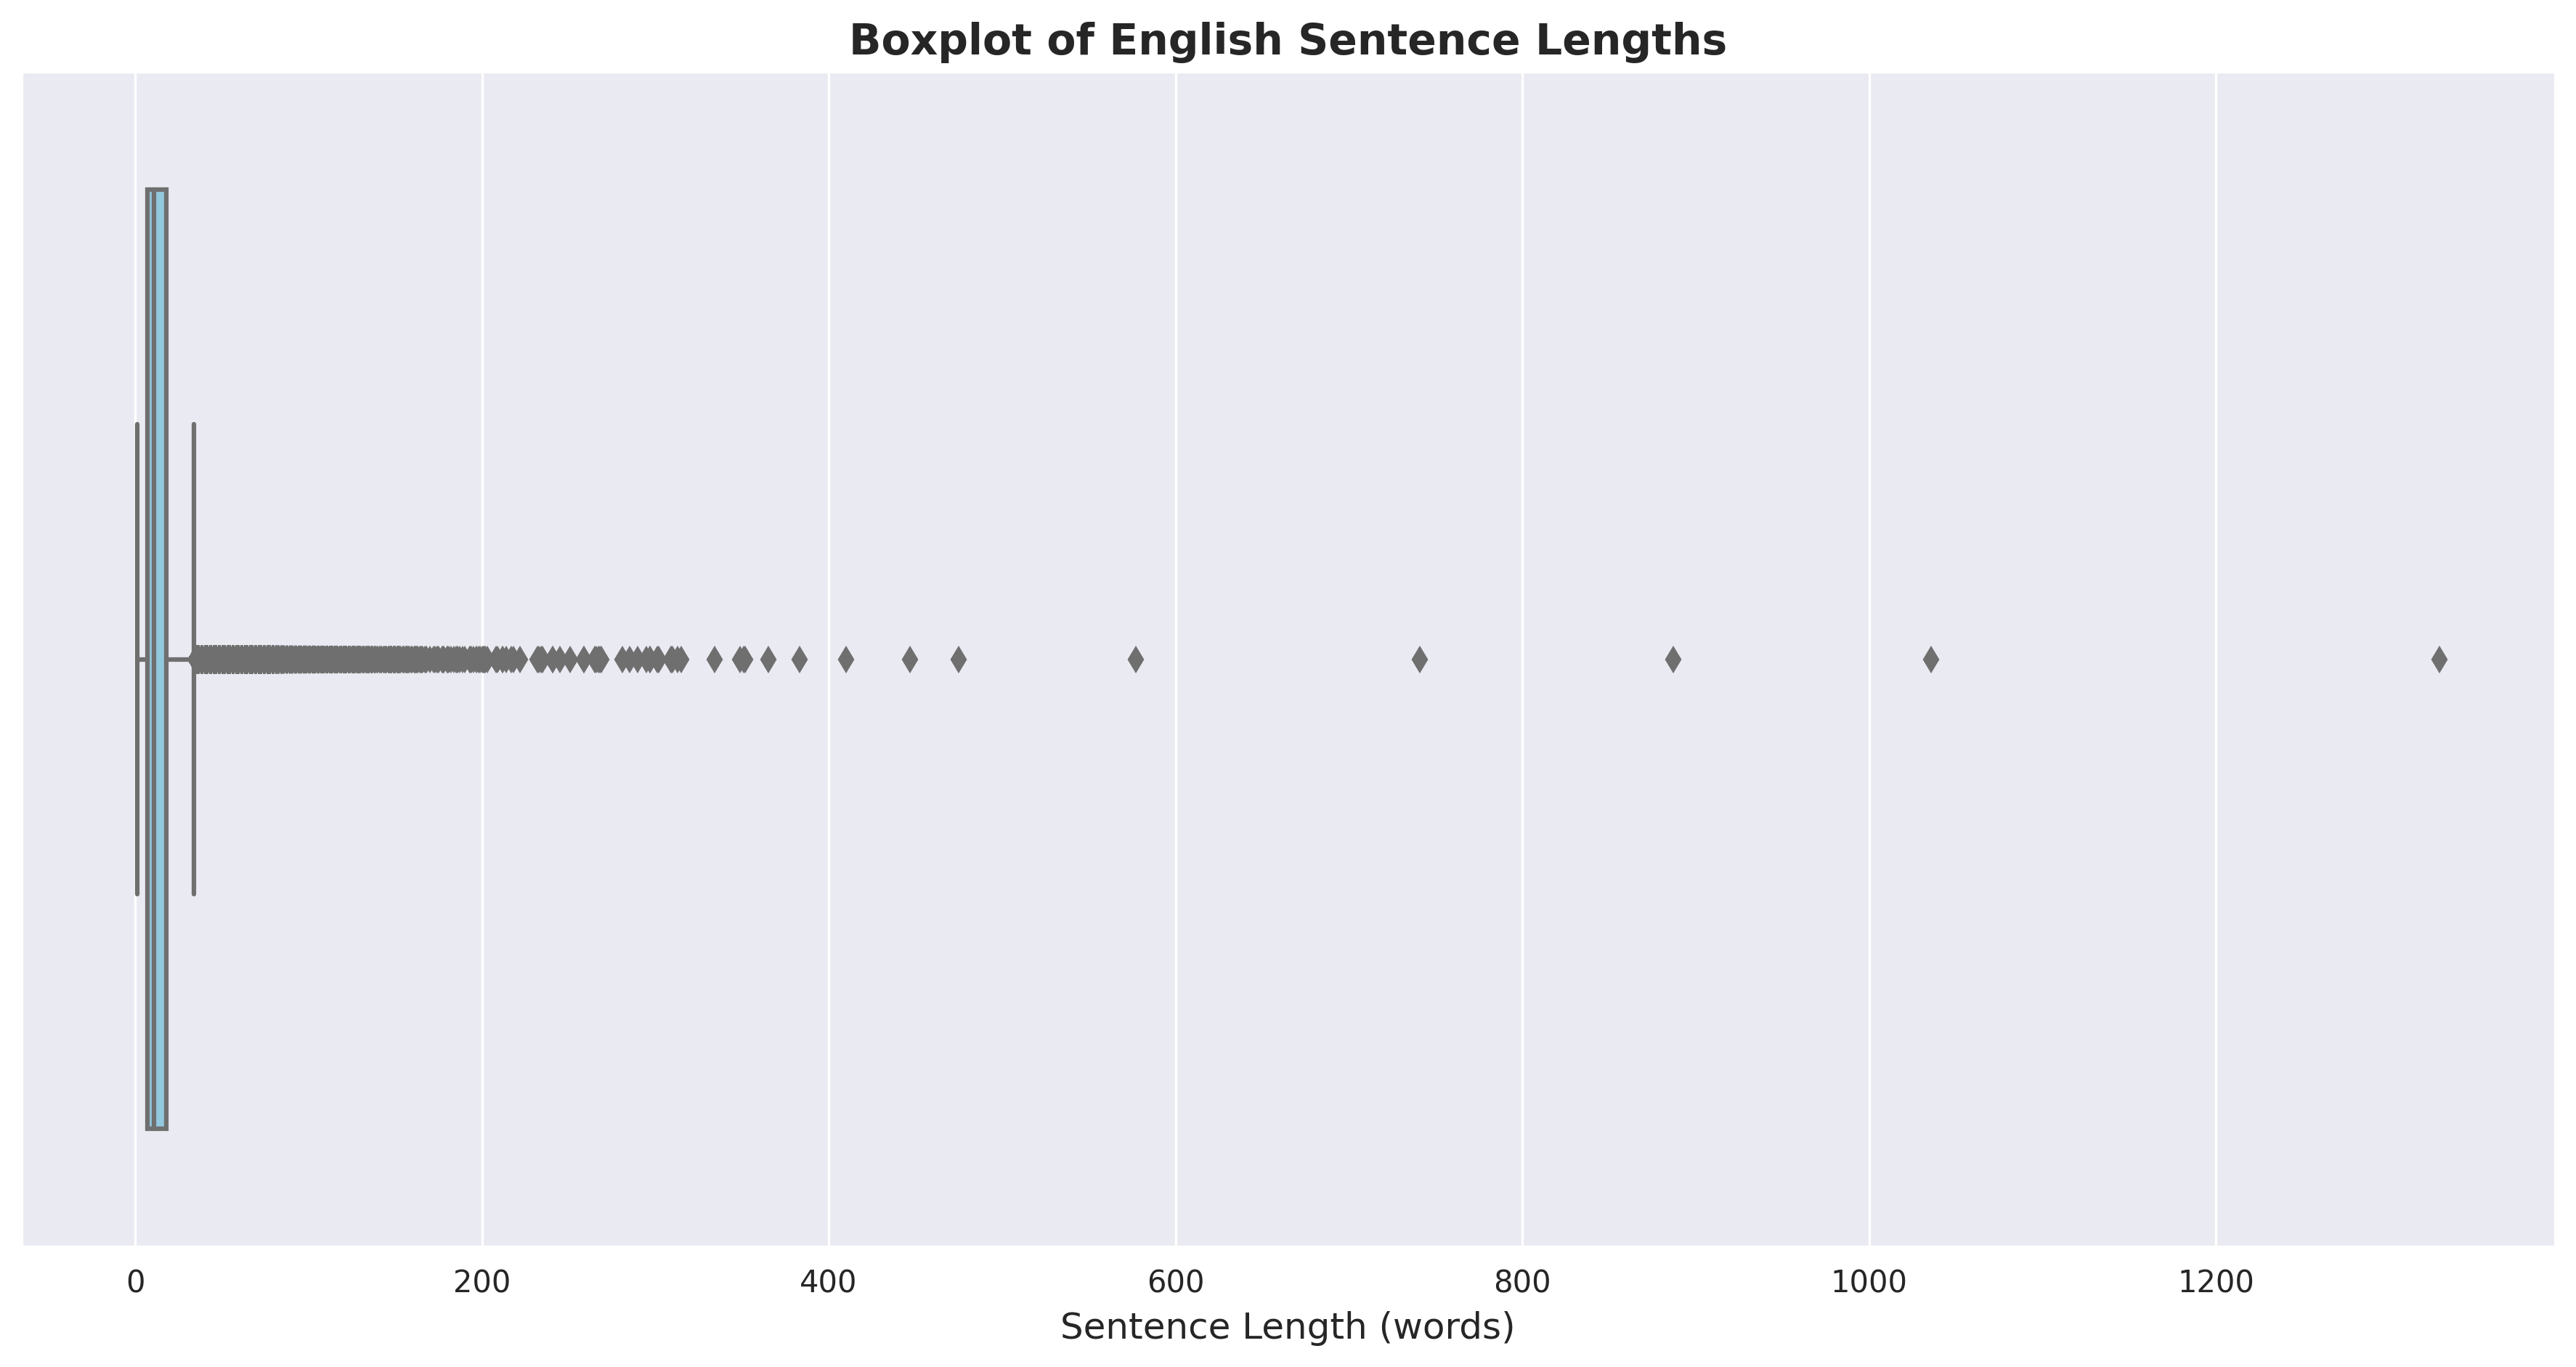

In [31]:
boxplot_sentence_lengths(envi_data['en_words_count'])

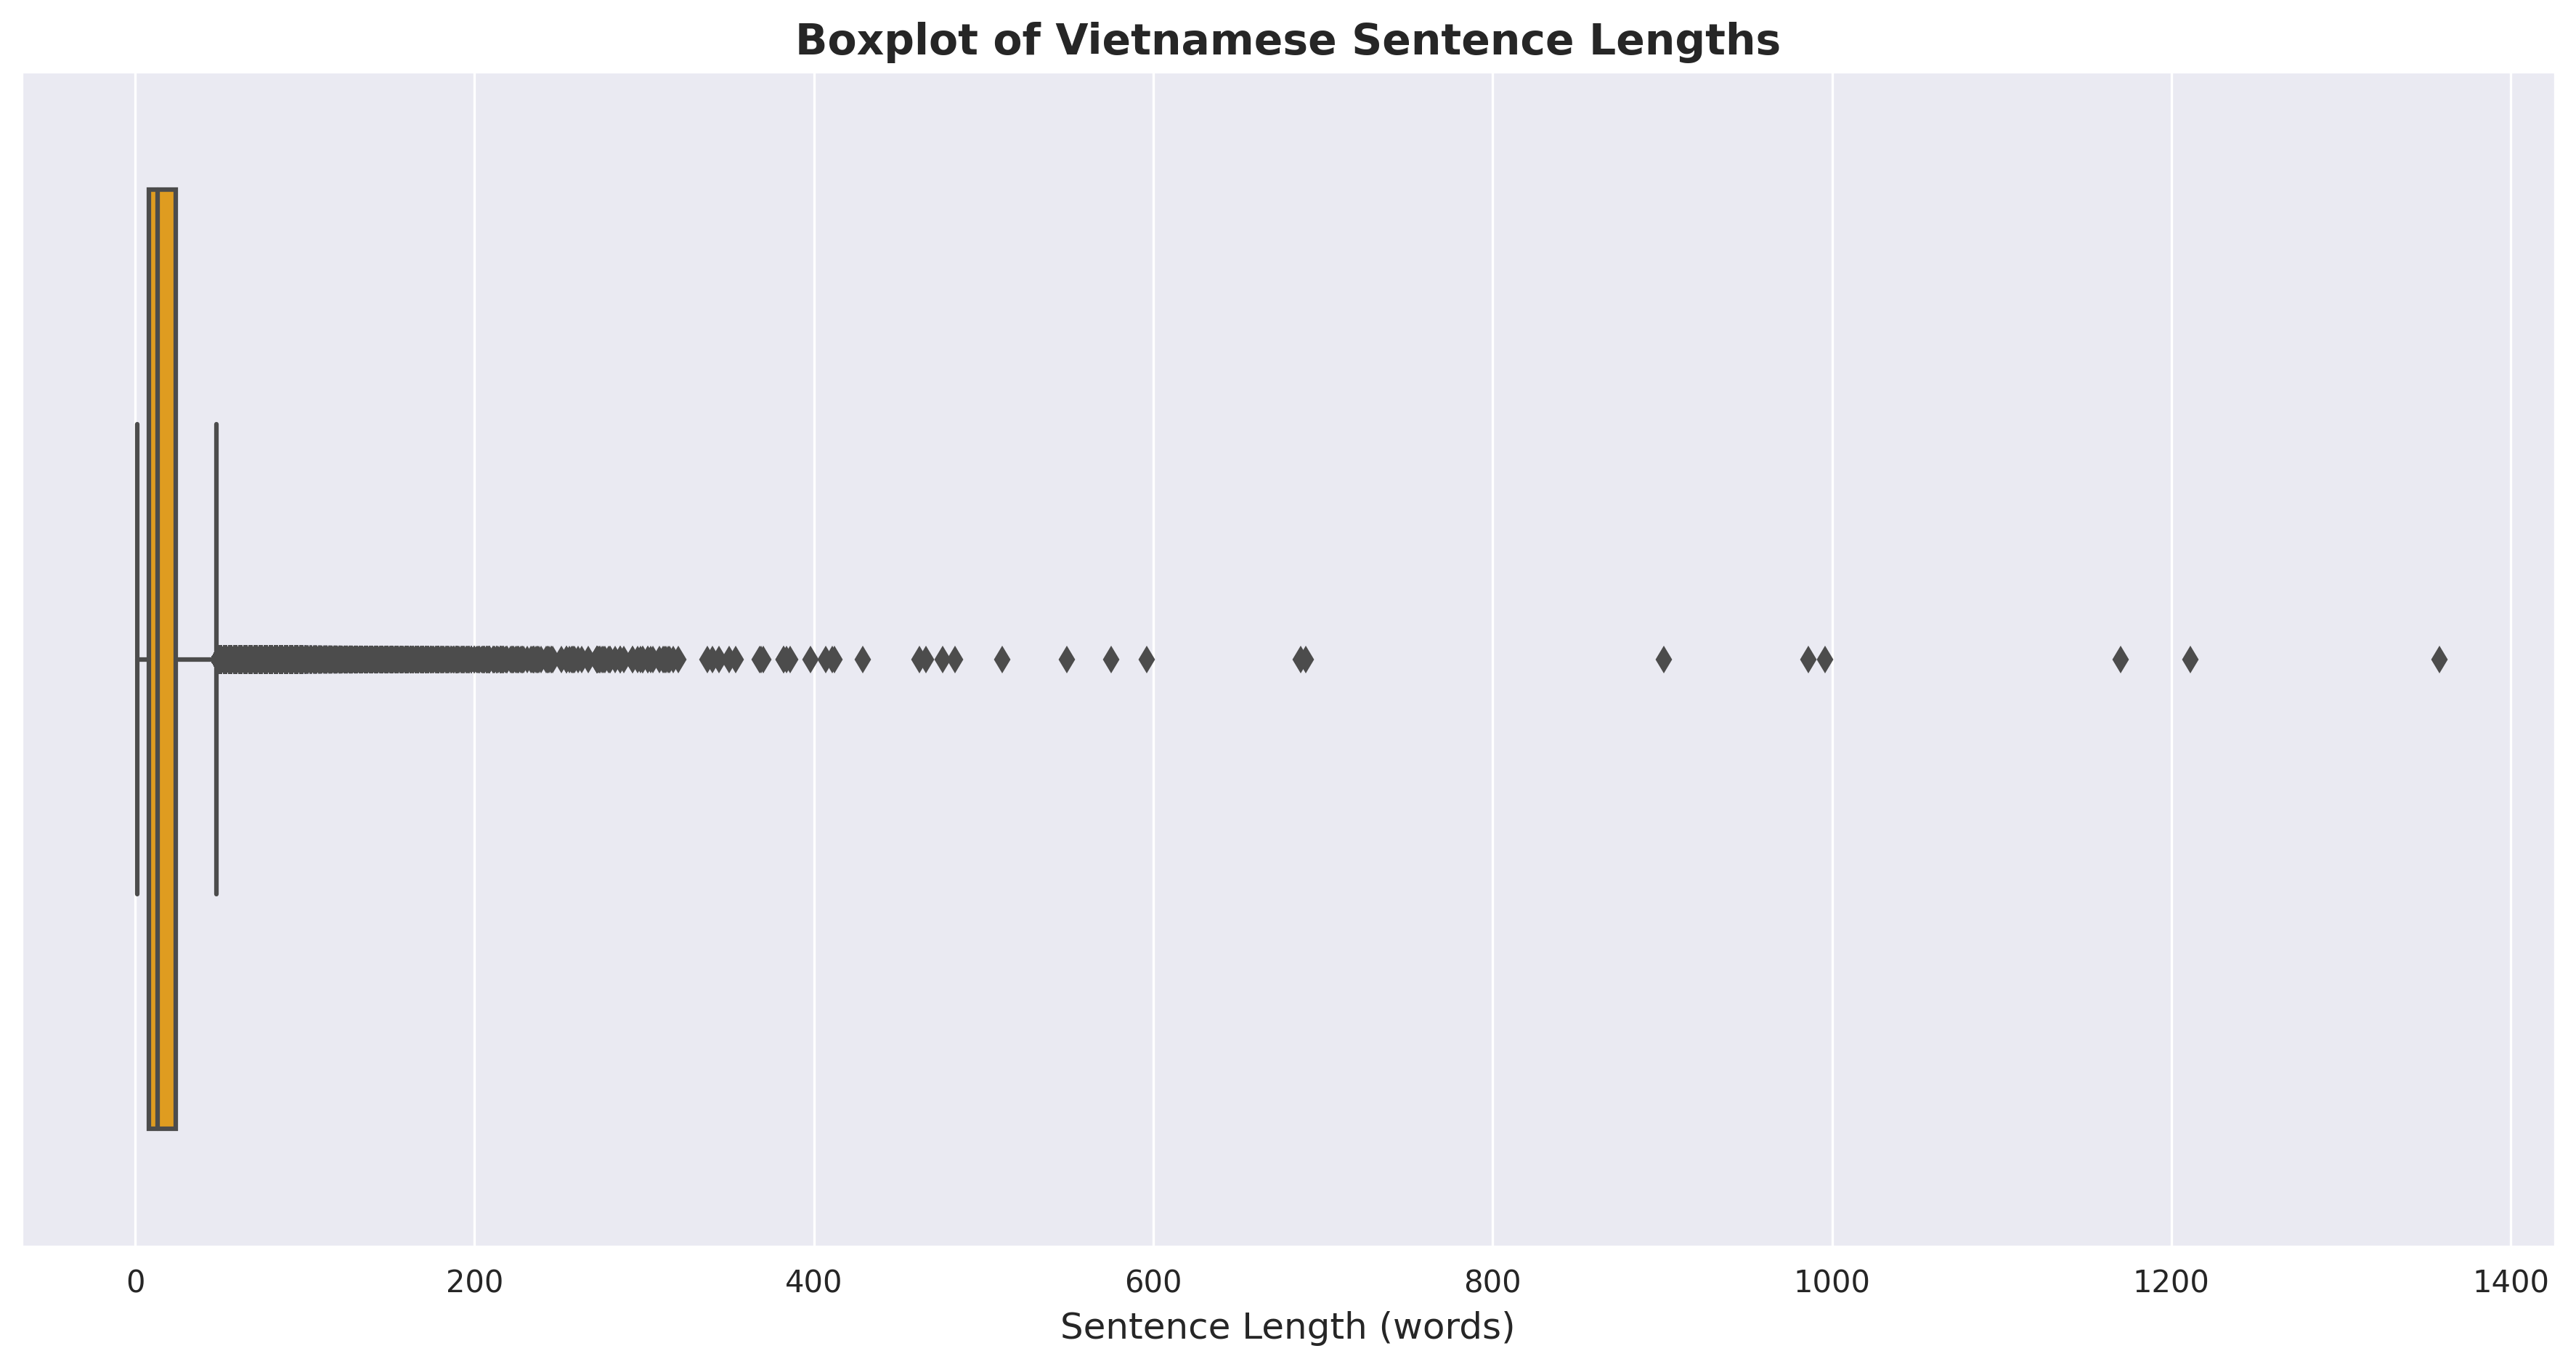

In [32]:
boxplot_sentence_lengths(envi_data['vi_words_count'], language='Vietnamese', color='orange')

The two boxplots above illustrate the distribution of sentence lengths (measured in words) for English and Vietnamese sentences in our dataset. We can observe that the majority of sentences are relatively short, concentrated around a narrow range. However, both languages exhibit numerous outliers, indicating the existence of unusually long sentences. Specifically, English sentences can extend up to approximately 1200 words, whereas Vietnamese sentences may reach nearly 1400 words.

In [ ]:
def zoomed_in_histogram(sentence_lengths, language='English', max_length=100):
    sns.set_style('darkgrid')
    plt.figure(figsize=(15, 7), dpi=300)
    
    filtered_lengths = [length for length in sentence_lengths if length <= max_length]
    
    sns.histplot(filtered_lengths, binwidth=1, kde=True, color='steelblue')
    plt.xlim(0, max_length)
    plt.xlabel('Sentence Length (words)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title(f'Zoomed-In Histogram (0 to {max_length} words) for {language} Sentences', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


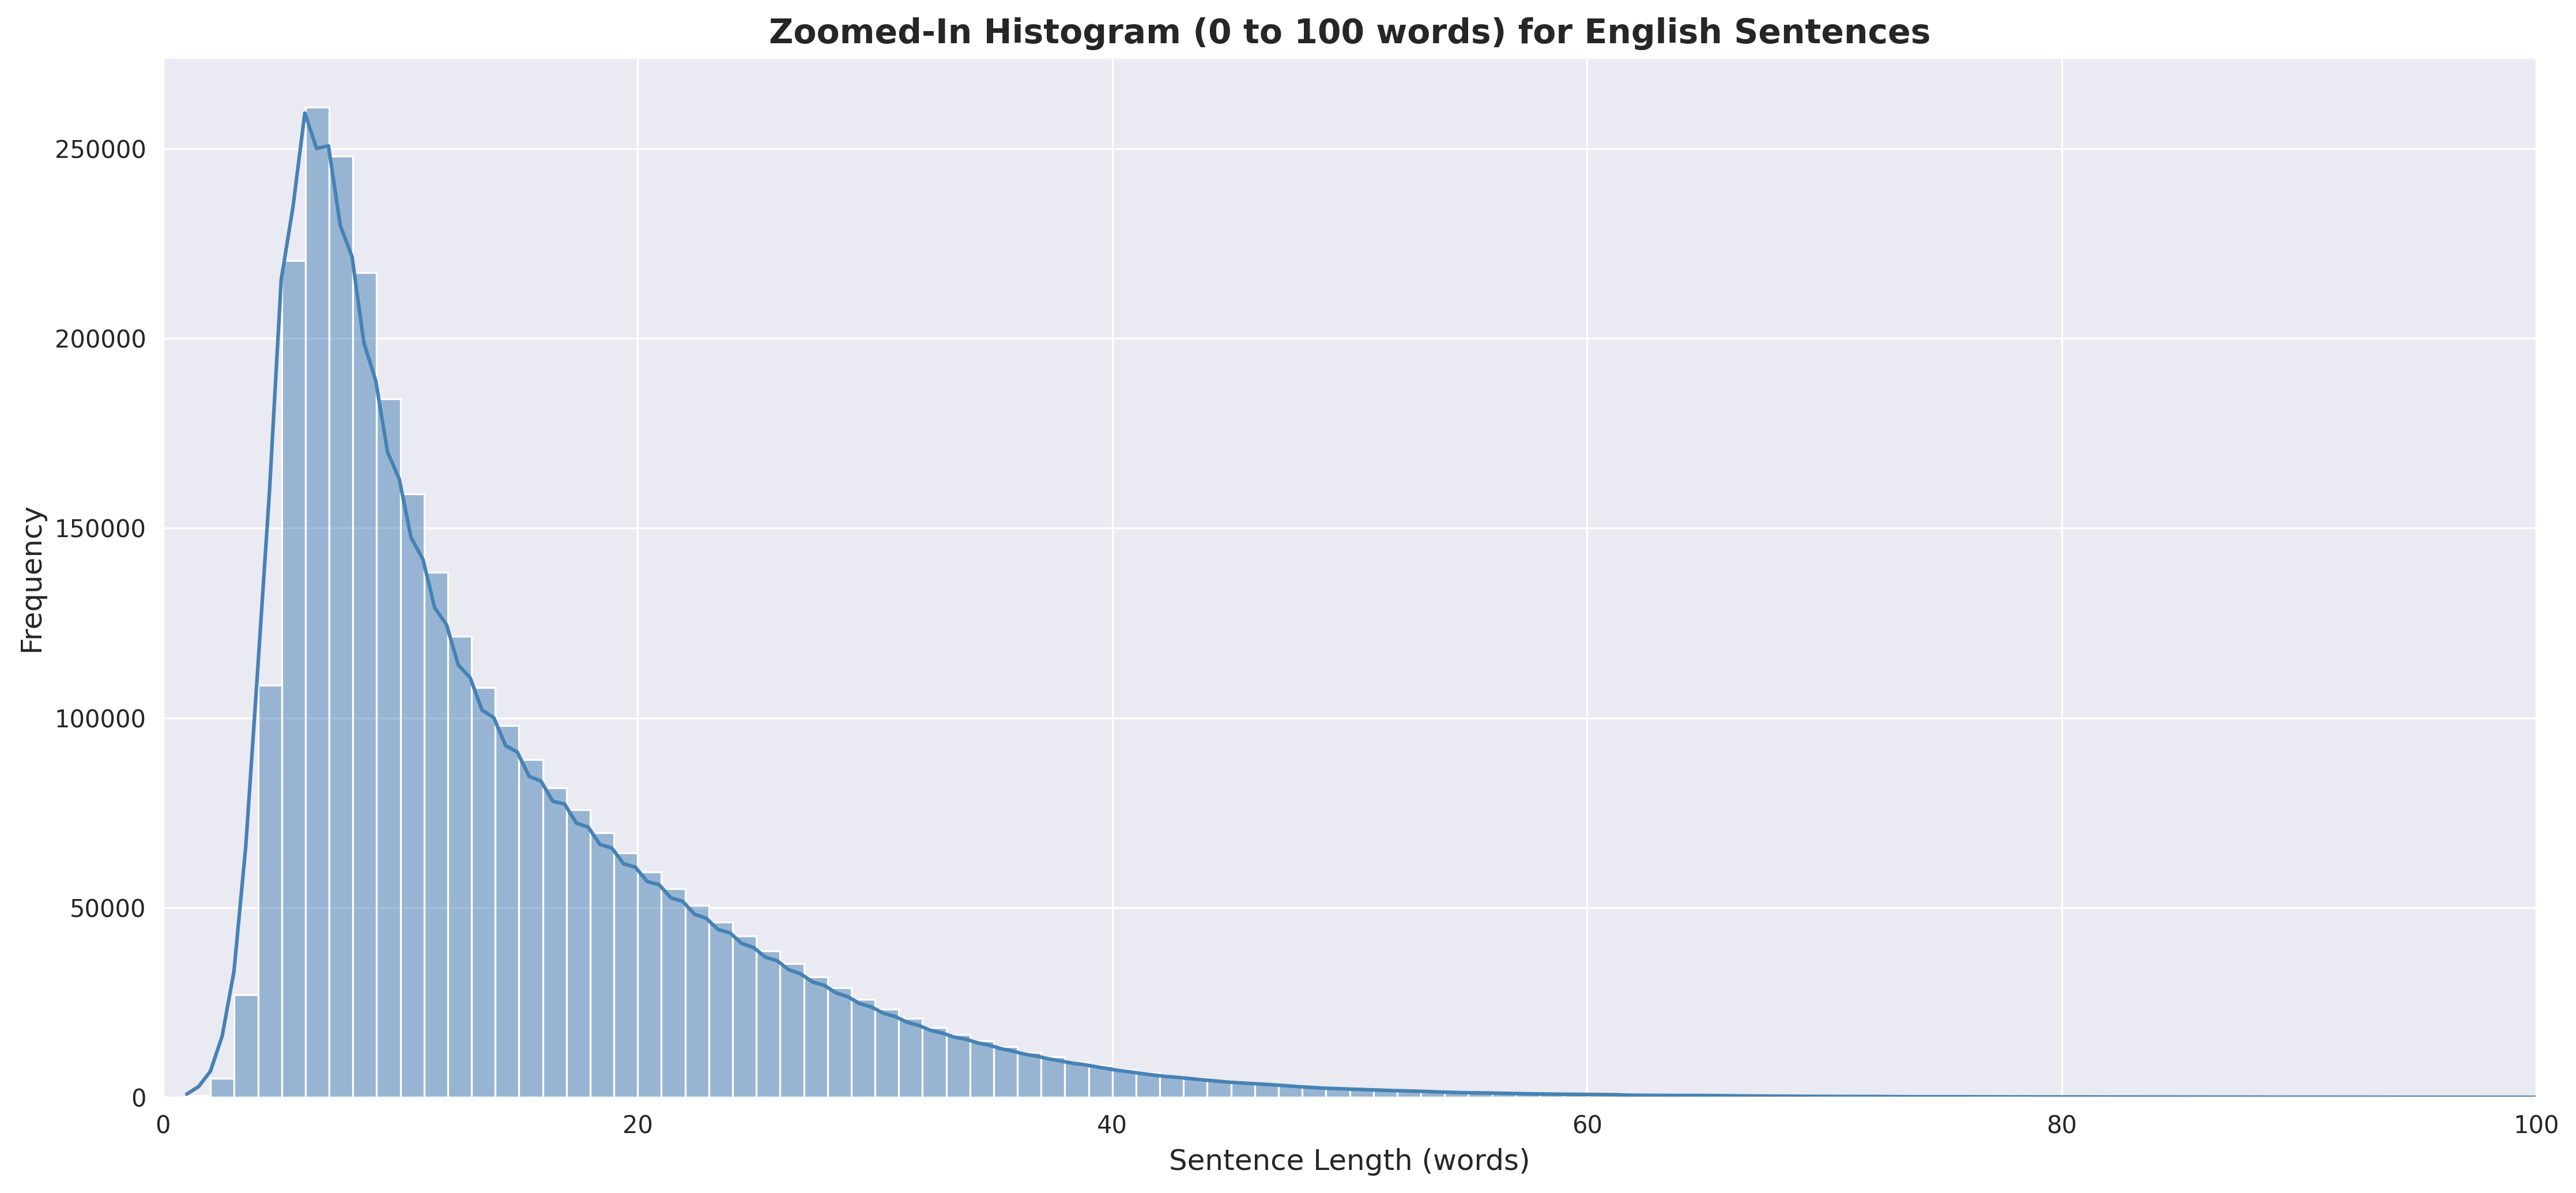

In [36]:
zoomed_in_histogram(envi_data['en_words_count'])

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


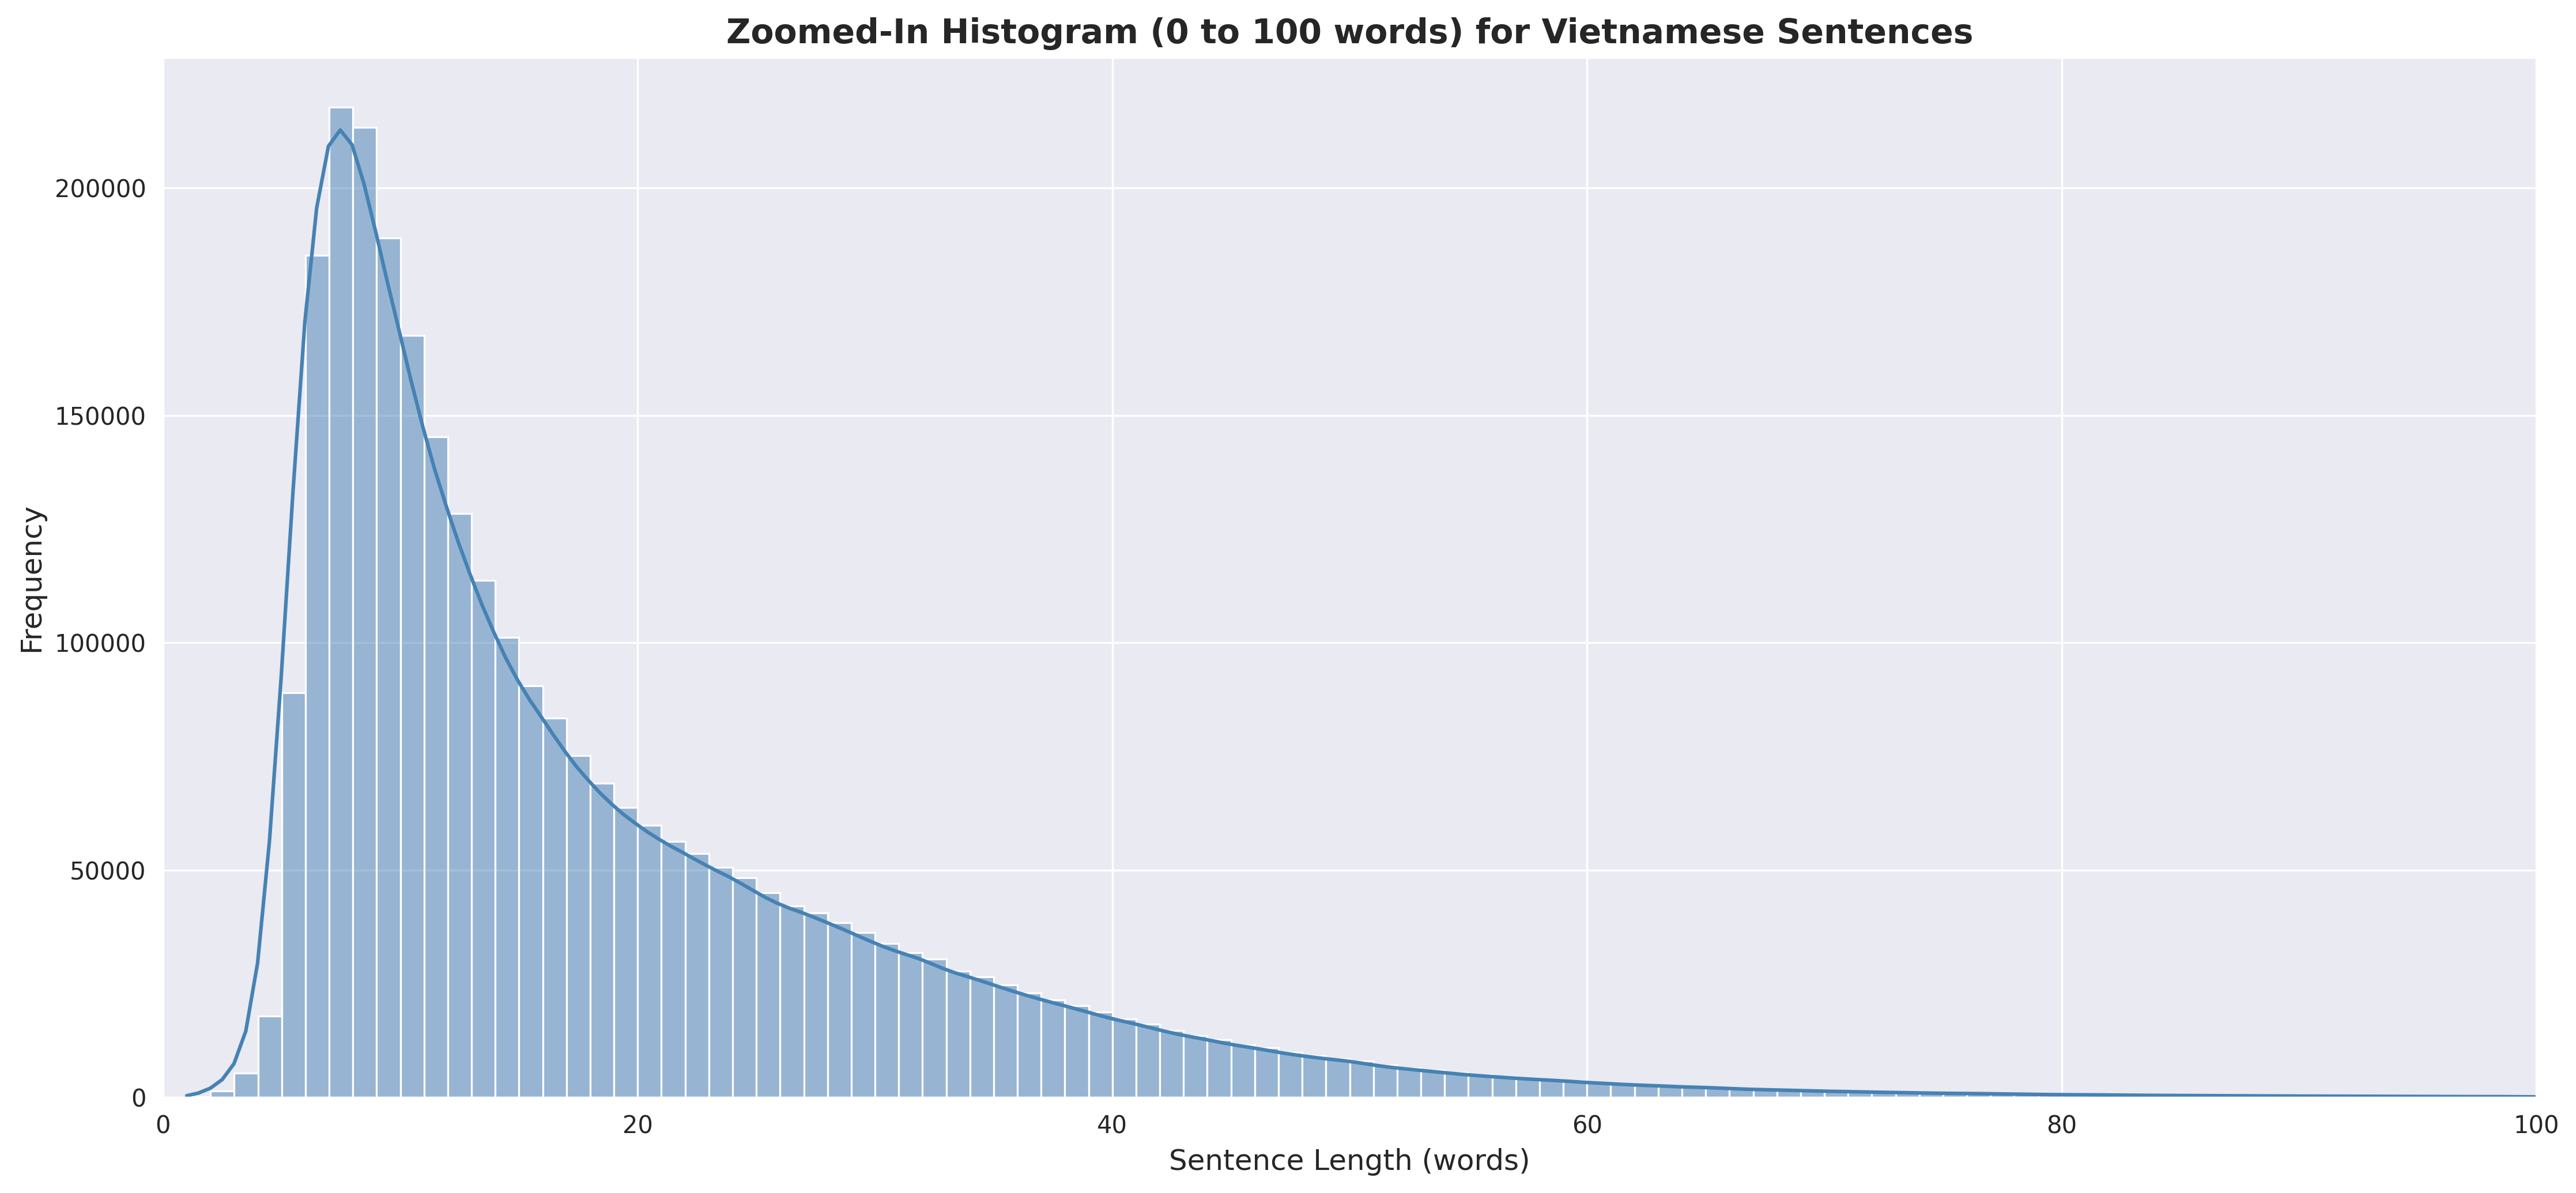

In [37]:
zoomed_in_histogram(envi_data['vi_words_count'], language='Vietnamese')

The two histograms above provide a closer look at the distribution of sentence lengths, ranging from 0 to 100 words, for both English and Vietnamese texts. It is evident that shorter sentences dominate in both languages, with the highest frequency occurring around 5 to 10 words. As sentence length increases, the frequency decreases sharply, indicating that most sentences in the dataset are concise and straightforward. This insight highlights the dataset's suitability for typical machine translation tasks.

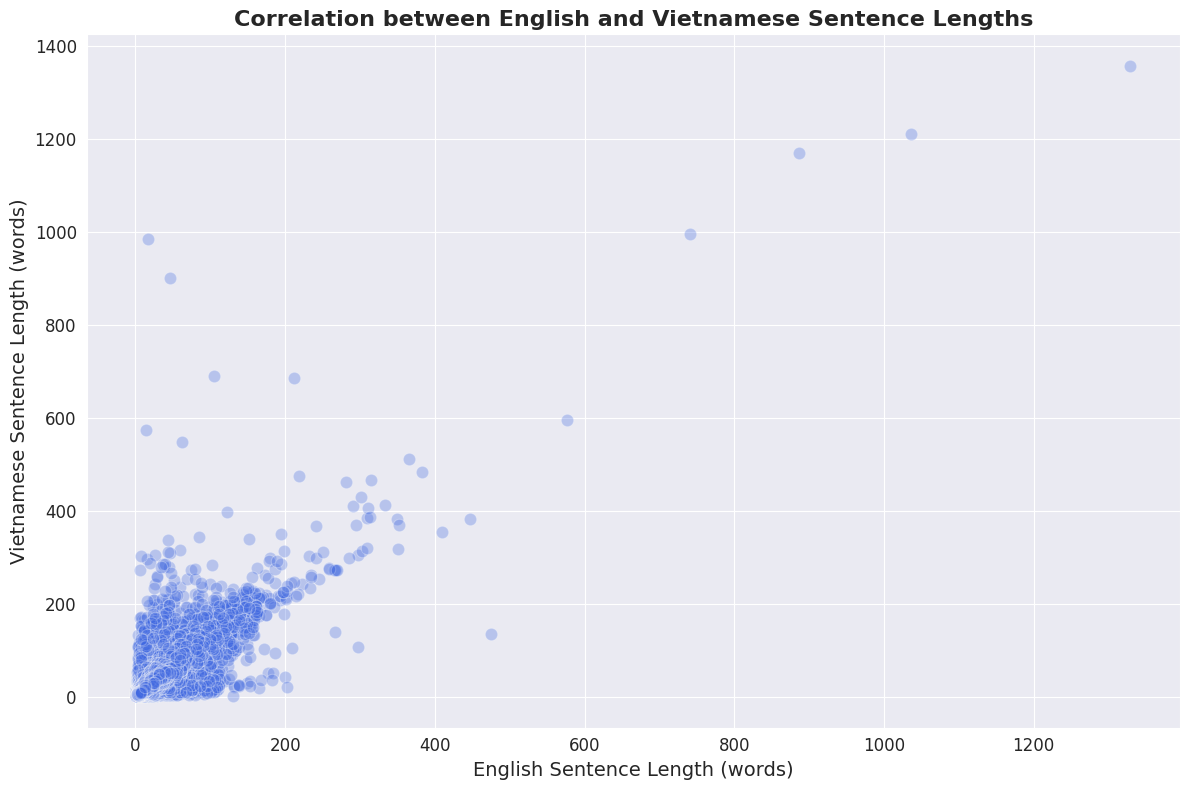

Correlation Matrix:
                 en_words_count  vi_words_count
en_words_count        1.000000        0.927183
vi_words_count        0.927183        1.000000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('darkgrid')
plt.figure(figsize=(12, 8))

scatter = sns.scatterplot(
    data=envi_data,
    x='en_words_count',
    y='vi_words_count',
    color='royalblue',
    edgecolor='w',
    s=80,        
    alpha=0.3,   
    marker='o'
)

plt.xlabel("English Sentence Length (words)", fontsize=14)
plt.ylabel("Vietnamese Sentence Length (words)", fontsize=14)
plt.title("Correlation between English and Vietnamese Sentence Lengths", fontsize=16, weight='bold')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

correlation = envi_data[['en_words_count', 'vi_words_count']].corr()
print("Correlation Matrix:\n", correlation)


The scatter plot shows a clear positive correlation between English and Vietnamese sentence lengths, indicating that longer English sentences generally correspond to longer Vietnamese sentences. Most sentence pairs are short and clustered closely together, but there are several noticeable outliers with extremely long lengths in both languages. These outliers might require special attention or preprocessing before training translation models.

**Word Frequency**

In [ ]:
import string
from collections import Counter

punctuation_to_remove = string.punctuation.replace("'", "")

translator = str.maketrans('', '', punctuation_to_remove)

english_text = " ".join(envi_data["en"])
vietnamese_text = " ".join(envi_data["vi"])

english_text = english_text.translate(translator)
vietnamese_text = vietnamese_text.translate(translator)

english_words = english_text.split()
vietnamese_words = vietnamese_text.split()

english_counter = Counter(english_words)
vietnamese_counter = Counter(vietnamese_words)


In [39]:
# english_counter

In [40]:
# vietnamese_counter

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from wordcloud import STOPWORDS

def plot_top_words_bar_chart(word_freq):
    filtered_word_freq = {word: freq for word, freq in word_freq.items() if word.lower() not in STOPWORDS}
    
    sorted_words = sorted(filtered_word_freq.items(), key=lambda x: x[1], reverse=True)[:10]
    words, frequencies = zip(*sorted_words)
    
    df = pd.DataFrame({'Word': words, 'Frequency': frequencies})
    
    df = df.sort_values(by='Frequency', ascending=False)
    
    sns.set_style("darkgrid")
    plt.figure(figsize=(10, 8))
    
    ax = sns.barplot(x='Word', y='Frequency', hue='Word', data=df, palette='magma', dodge=False)
    if ax.get_legend() is not None:
        ax.legend_.remove()  
    
    plt.title("Top 10 Word Occurrences", fontsize=16, weight='bold')
    plt.xlabel("Words", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.xticks(rotation=0, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    
    plt.tight_layout()
    plt.show()


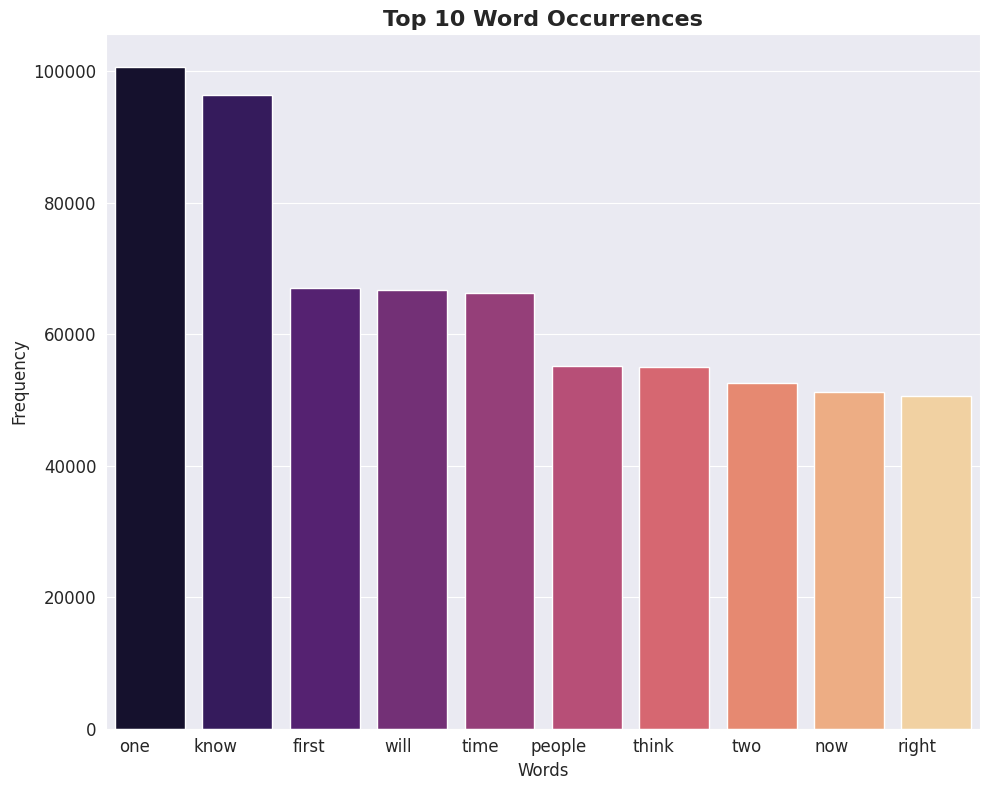

In [42]:
plot_top_words_bar_chart(english_counter)

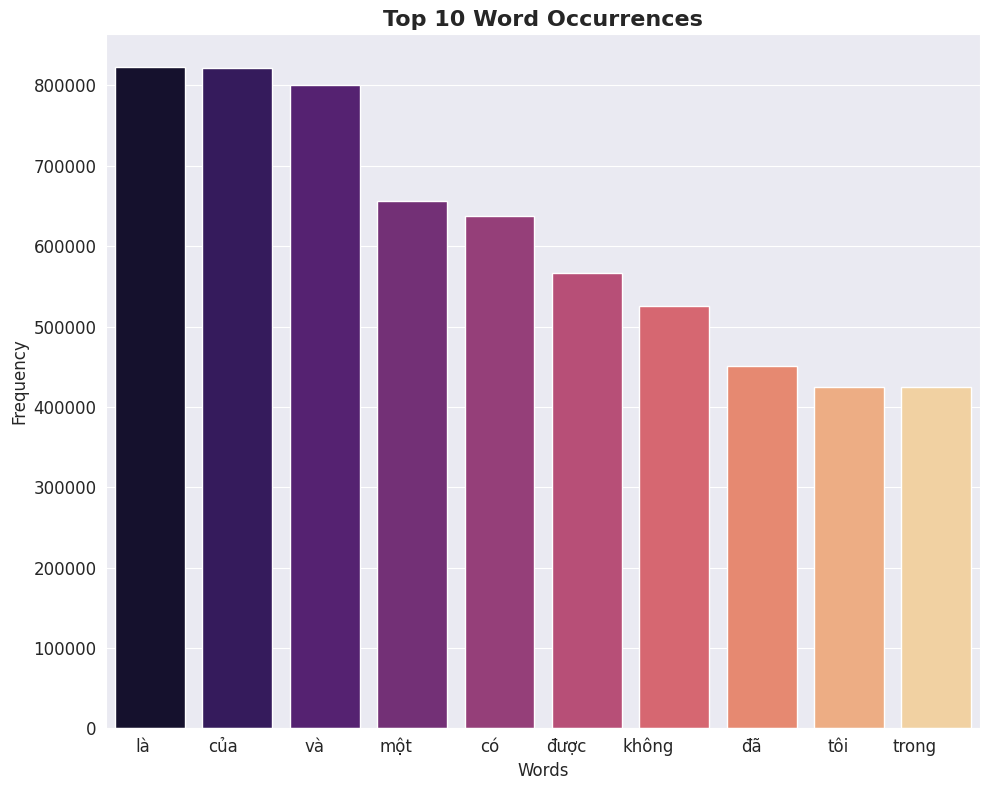

In [43]:
plot_top_words_bar_chart(vietnamese_counter)

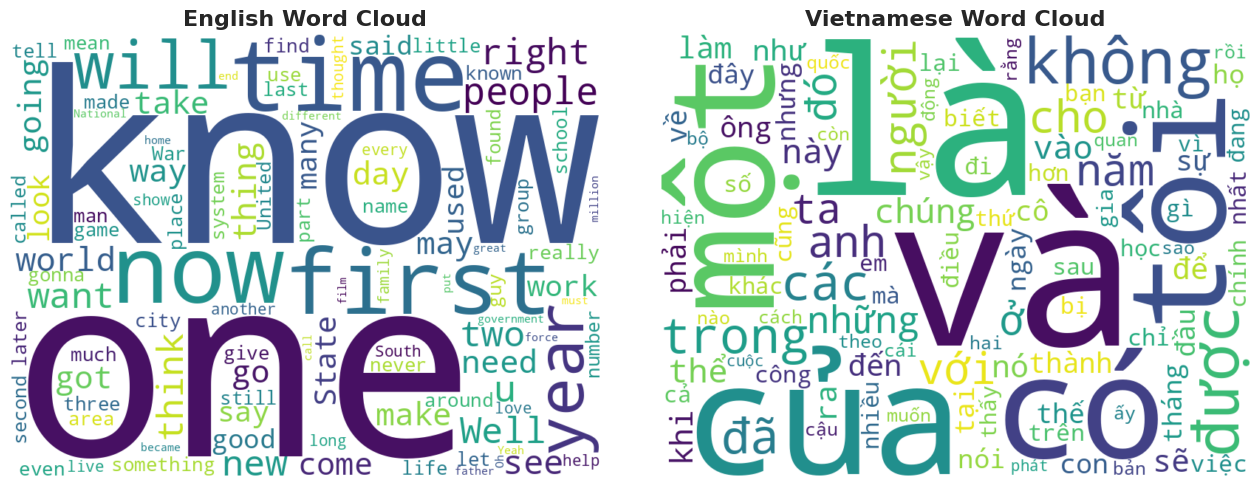

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

english_wc = WordCloud(
    width=800,
    height=600,
    background_color="white",
    max_words=100,
    colormap="viridis",   
    collocations=False,   
    contour_width=2,       
    contour_color="steelblue"
).generate(english_text)

vietnamese_wc = WordCloud(
    width=800,
    height=600,
    background_color="white",
    max_words=100,
    colormap="viridis",      
    collocations=False,
    contour_width=2,
    contour_color="steelblue"
).generate(vietnamese_text)

plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(english_wc, interpolation="bilinear")
plt.axis("off")
plt.title("English Word Cloud", fontsize=16, weight="bold")

plt.subplot(1, 2, 2)
plt.imshow(vietnamese_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Vietnamese Word Cloud", fontsize=16, weight="bold")

plt.subplots_adjust(wspace=0.1)
plt.show()


The word clouds and the bar charts above visually represent the most frequent words in the English and Vietnamese parts of our dataset. In the English word cloud, prominent words like "one," "know," "time," and "first" stand out clearly. Meanwhile, the Vietnamese word cloud emphasizes commonly used words such as "là," "và," "của," and "có," which are crucial grammatical elements in Vietnamese. These visuals help illustrate the linguistic differences between the two languages and highlight important vocabulary to focus on when developing and optimizing translation models.

### **N-gram Analysis**

In [45]:
from sklearn.feature_extraction.text import CountVectorizer

In [46]:
def get_top_ngram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx])
                  for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:10]

In [47]:
top_en_bigram = get_top_ngram(envi_data['en'], n=2)
top_en_trigram = get_top_ngram(envi_data['en'], n=3)

In [48]:
top_vi_bigram = get_top_ngram(envi_data['vi'], n=2)
top_vi_trigram = get_top_ngram(envi_data['vi'], n=3)

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


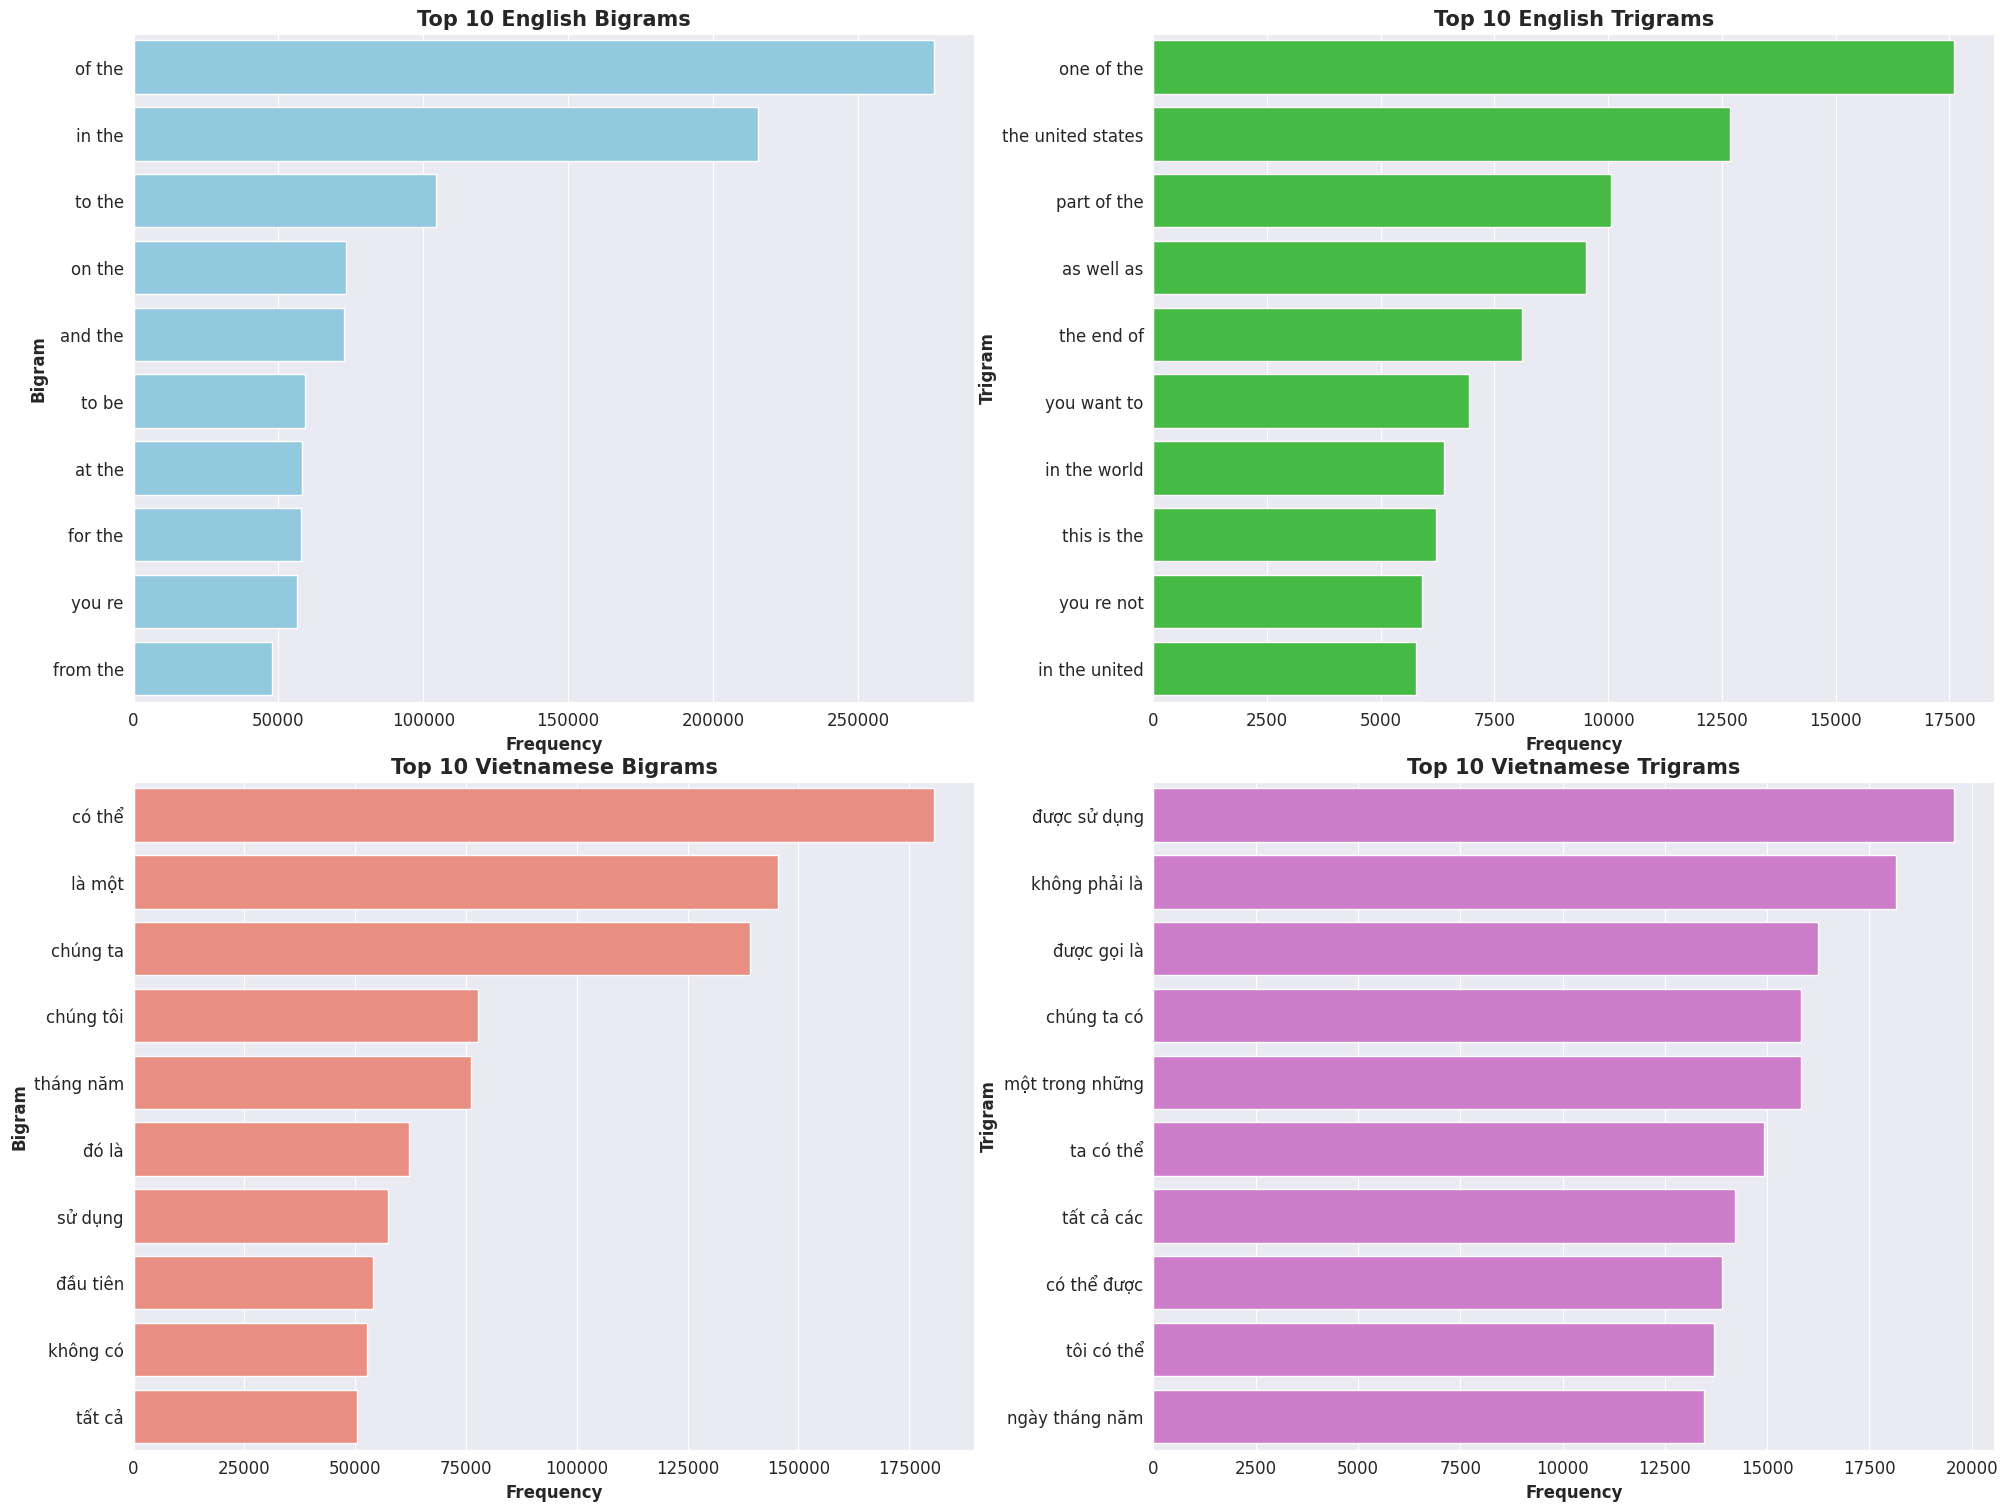

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

fig, axes = plt.subplots(2, 2, figsize=(20, 15))

# --- Top 10 English Bigrams ---
en_bigram_words, en_bigram_freq = map(list, zip(*top_en_bigram))
sns.barplot(x=en_bigram_freq, y=en_bigram_words, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_xlabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Bigram', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Top 10 English Bigrams', fontsize=15, fontweight='bold')
axes[0, 0].tick_params(axis='both', labelsize=12)

# --- Top 10 English Trigrams ---
en_trigram_words, en_trigram_freq = map(list, zip(*top_en_trigram))
sns.barplot(x=en_trigram_freq, y=en_trigram_words, color='limegreen', ax=axes[0, 1])
axes[0, 1].set_xlabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Trigram', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Top 10 English Trigrams', fontsize=15, fontweight='bold')
axes[0, 1].tick_params(axis='both', labelsize=12)

# --- Top 10 Vietnamese Bigrams ---
vi_bigram_words, vi_bigram_freq = map(list, zip(*top_vi_bigram))
sns.barplot(x=vi_bigram_freq, y=vi_bigram_words, color='salmon', ax=axes[1, 0])
axes[1, 0].set_xlabel('Frequency', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Bigram', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Top 10 Vietnamese Bigrams', fontsize=15, fontweight='bold')
axes[1, 0].tick_params(axis='both', labelsize=12)

# --- Top 10 Vietnamese Trigrams ---
vi_trigram_words, vi_trigram_freq = map(list, zip(*top_vi_trigram))
sns.barplot(x=vi_trigram_freq, y=vi_trigram_words, color='orchid', ax=axes[1, 1])
axes[1, 1].set_xlabel('Frequency', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Trigram', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Top 10 Vietnamese Trigrams', fontsize=15, fontweight='bold')
axes[1, 1].tick_params(axis='both', labelsize=12)

# Adjust spacing between subplots for clarity
plt.tight_layout(pad=0.3)
plt.show()



The bar charts above display the most frequent bigrams and trigrams for both English and Vietnamese sentences within the dataset. Common English bigrams include phrases like "of the," "in the," and "to the," while frequently occurring English trigrams include "one of the" and "the united states." For Vietnamese, common bigrams such as "có thể," "là một," and "chúng ta" appear frequently, while common trigrams include expressions like "được sử dụng," "không phải là," and "được gọi là." These frequent phrases highlight linguistic patterns in each language and provide insights that can enhance translation model design and performance.